Dataset
X shape: (926, 8)
Y shape: (926,)

Main cross-validation folds
Fold 1: 186 samples
Fold 2: 185 samples
Fold 3: 185 samples
Fold 4: 185 samples
Fold 5: 185 samples

Baseline model comparison
Linear                       | features =   9 | train MSE = 108.9949 | CV MSE = 112.1293 +/- 8.4182
Powers degree 2              | features =  17 | train MSE =  62.9157 | CV MSE =  66.9643 +/- 4.9895
Powers degree 3              | features =  25 | train MSE =  44.2265 | CV MSE =  47.6211 +/- 4.6585
Powers degree 4              | features =  33 | train MSE =  38.0838 | CV MSE =  41.8818 +/- 2.4046
Quadratic interactions       | features =  45 | train MSE =  51.8913 | CV MSE =  61.4237 +/- 6.2363
Combined nonlinear           | features =  57 | train MSE =  30.6778 | CV MSE =  36.6593 +/- 4.7853

Cross-validation comparison across K

K = 3
----------------------------------------------------------------------------------------------------
Linear                       | train MSE = 108.5441 | CV

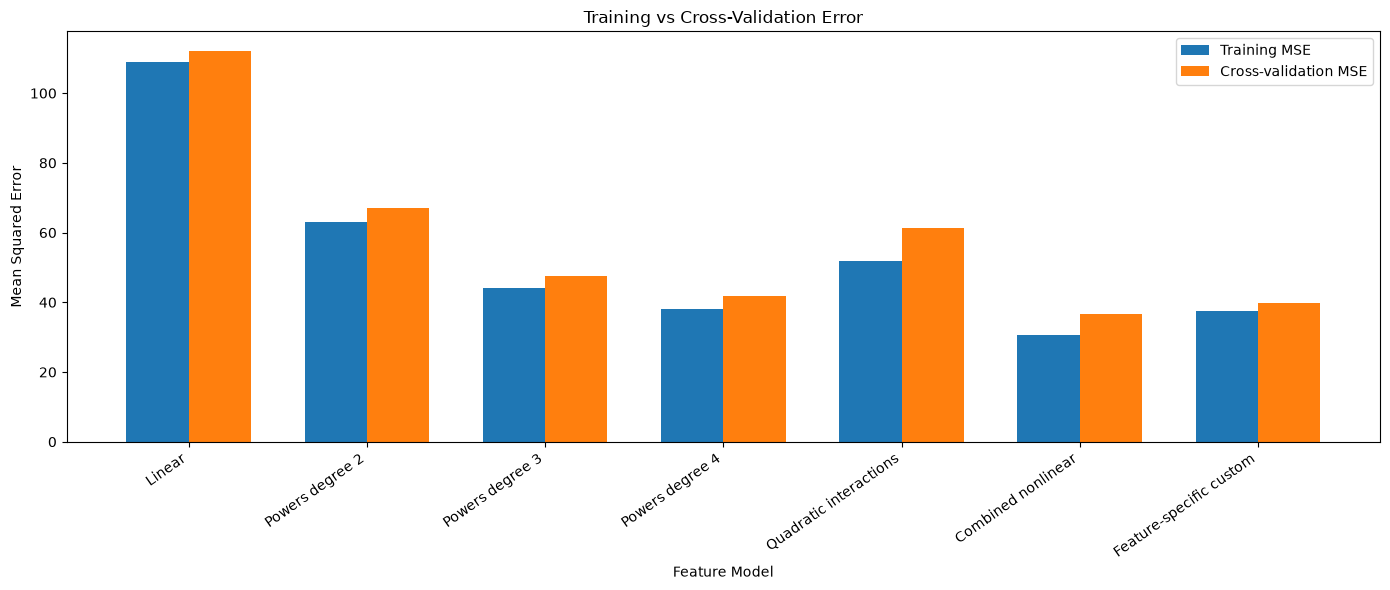

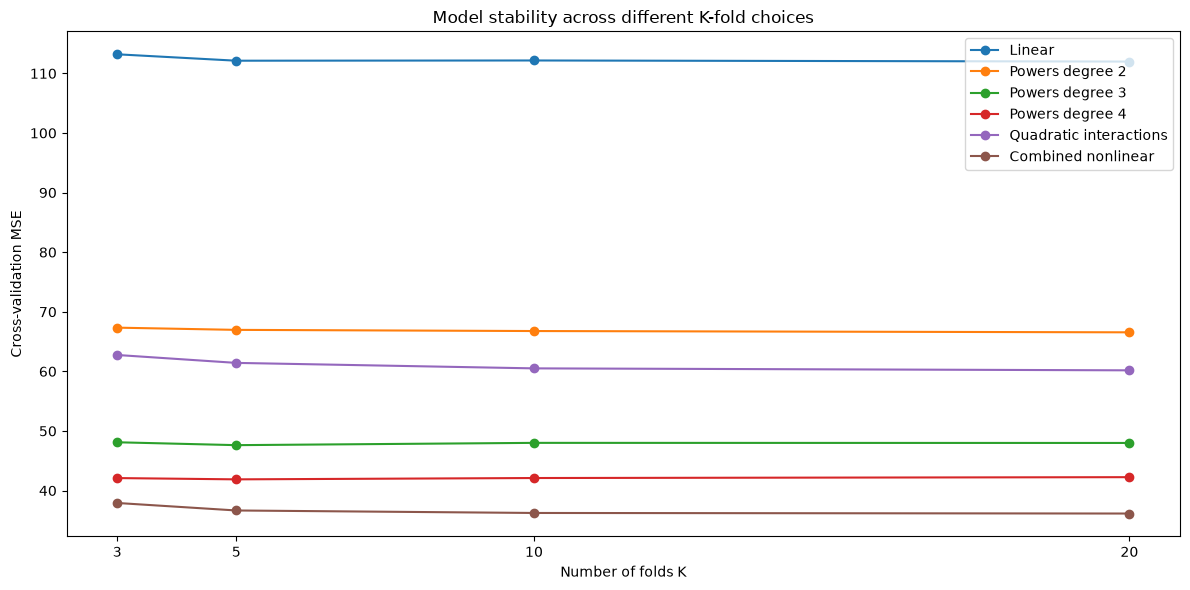


Final fitted model
Selected model: Combined nonlinear
Number of features: 57
Final training MSE: 31.23477255000391
Estimated test MSE from CV: 36.659297174260175

Official test set
Shape: (103, 8)
Saved 103 predictions to predictions.txt
Sanity checks passed.


In [3]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Load training data
# ============================================================

traindata = np.loadtxt("traindata.txt")

X = traindata[:, :8]
Y = traindata[:, 8]

print("Dataset")
print("=" * 60)
print("X shape:", X.shape)
print("Y shape:", Y.shape)


# ============================================================
# 2. Least-squares regression
# ============================================================

def least_squares(Z, y):

    Z = np.asarray(Z)
    y = np.asarray(y).flatten()

    w, _, _, _ = np.linalg.lstsq(
        Z,
        y,
        rcond=None
    )

    return w


# ============================================================
# 3. Mean squared error
# ============================================================

def calculate_mse(w, Z, y):

    predictions = Z @ w

    return np.mean(
        (predictions - y) ** 2
    )


# ============================================================
# 4. Basic feature models
# ============================================================

def linear_basis(X):

    return np.hstack([
        np.ones((len(X), 1)),
        X
    ])


def polynomial_basis(X, degree):

    features = [
        np.ones((len(X), 1))
    ]

    for d in range(
        1,
        degree + 1
    ):

        features.append(
            X ** d
        )

    return np.hstack(features)


def quadratic_interaction_basis(X):

    features = [
        np.ones((len(X), 1)),
        X,
        X ** 2
    ]

    n_features = X.shape[1]

    for i in range(n_features):

        for j in range(
            i + 1,
            n_features
        ):

            interaction = (
                X[:, i] *
                X[:, j]
            ).reshape(-1, 1)

            features.append(
                interaction
            )

    return np.hstack(features)


def nonlinear_basis(X):

    return np.hstack([

        np.ones((len(X), 1)),

        X,

        X ** 2,

        np.log1p(
            np.abs(X)
        ),

        np.sqrt(
            np.abs(X)
        ),

        np.sin(X),

        np.cos(X),

        1.0 /
        (
            1.0 +
            np.abs(X)
        )
    ])


# ============================================================
# 5. Cross-validation fold helper
# ============================================================

RANDOM_SEED = 42

def make_folds(n_samples, K, seed=RANDOM_SEED):
    """
    Create shuffled K-fold splits reproducibly.
    """
    rng = np.random.default_rng(seed)

    indices = np.arange(n_samples)
    rng.shuffle(indices)

    return np.array_split(
        indices,
        K
    )


# We will use this as the main fold count for model selection.
# Later we compare several K values.
MAIN_K = 5

folds = make_folds(
    len(X),
    MAIN_K,
    RANDOM_SEED
)

print("\nMain cross-validation folds")
print("=" * 60)

for i, fold in enumerate(folds):
    print(
        f"Fold {i + 1}: "
        f"{len(fold)} samples"
    )


# ============================================================
# 6. Generic cross-validation function
# ============================================================

def cross_validate_model(
    X,
    y,
    feature_function,
    folds
):

    train_mse_values = []
    val_mse_values = []

    for k in range(
        len(folds)
    ):

        # Current fold = validation
        val_idx = folds[k]

        # All other folds = training
        train_idx = np.concatenate([
            folds[j]
            for j in range(len(folds))
            if j != k
        ])

        X_train = X[train_idx]
        y_train = y[train_idx]

        X_val = X[val_idx]
        y_val = y[val_idx]

        # Create feature matrices
        Z_train = feature_function(
            X_train
        )

        Z_val = feature_function(
            X_val
        )

        # Fit model
        w = least_squares(
            Z_train,
            y_train
        )

        # Calculate errors
        train_mse = calculate_mse(
            w,
            Z_train,
            y_train
        )

        val_mse = calculate_mse(
            w,
            Z_val,
            y_val
        )

        train_mse_values.append(
            train_mse
        )

        val_mse_values.append(
            val_mse
        )

    return {

        "train_mse":
            np.mean(
                train_mse_values
            ),

        "val_mse":
            np.mean(
                val_mse_values
            ),

        "val_std":
            np.std(
                val_mse_values,
                ddof=1
            ),

        "fold_train_mse":
            train_mse_values,

        "fold_val_mse":
            val_mse_values
    }


# ============================================================
# 7. Baseline model comparison
# ============================================================

baseline_models = {

    "Linear":
        linear_basis,

    "Powers degree 2":
        lambda X:
        polynomial_basis(X, 2),

    "Powers degree 3":
        lambda X:
        polynomial_basis(X, 3),

    "Powers degree 4":
        lambda X:
        polynomial_basis(X, 4),

    "Quadratic interactions":
        quadratic_interaction_basis,

    "Combined nonlinear":
        nonlinear_basis
}


baseline_results = {}

print("\nBaseline model comparison")
print("=" * 90)

for name, feature_function in baseline_models.items():

    result = cross_validate_model(
        X,
        Y,
        feature_function,
        folds
    )

    baseline_results[name] = result

    Z_temp = feature_function(X)

    print(
        f"{name:28s}"
        f" | features = {Z_temp.shape[1]:3d}"
        f" | train MSE = {result['train_mse']:8.4f}"
        f" | CV MSE = {result['val_mse']:8.4f}"
        f" +/- {result['val_std']:.4f}"
    )


# ============================================================
# 9. Compare different K-fold choices
# ============================================================

K_VALUES = [
    3,
    5,
    10,
    20
]

fold_comparison_results = {}

print("\nCross-validation comparison across K")
print("=" * 100)

for K_value in K_VALUES:

    folds_K = make_folds(
        len(X),
        K_value,
        RANDOM_SEED
    )

    fold_comparison_results[K_value] = {}

    print(
        f"\nK = {K_value}"
    )

    print(
        "-" * 100
    )

    for name, feature_function in baseline_models.items():

        result = cross_validate_model(
            X,
            Y,
            feature_function,
            folds_K
        )

        fold_comparison_results[K_value][name] = result

        print(
            f"{name:28s}"
            f" | train MSE = {result['train_mse']:8.4f}"
            f" | CV MSE = {result['val_mse']:8.4f}"
            f" +/- {result['val_std']:.4f}"
        )


print("\nBest model for each K")
print("=" * 80)

best_by_K = {}

for K_value in K_VALUES:

    results_K = fold_comparison_results[
        K_value
    ]

    best_name_K = min(
        results_K,
        key=lambda name:
            results_K[name]["val_mse"]
    )

    best_by_K[K_value] = best_name_K

    best_result_K = results_K[
        best_name_K
    ]

    print(
        f"K = {K_value:2d}"
        f" | best model = {best_name_K:28s}"
        f" | CV MSE = {best_result_K['val_mse']:.4f}"
    )


# ============================================================
# 10. Inspect each original predictor
# ============================================================

# ============================================================

print("\nFeature information")
print("=" * 60)

for j in range(
    X.shape[1]
):

    unique_values = np.unique(
        X[:, j]
    )

    print(
        f"\nx{j + 1}: "
        f"{len(unique_values)} unique values"
    )

    print(
        "min =",
        np.min(X[:, j])
    )

    print(
        "max =",
        np.max(X[:, j])
    )

    if len(unique_values) <= 30:

        print(
            "values =",
            unique_values
        )


# ============================================================
# 11. Feature-specific transformation builder
# ============================================================

def build_custom_basis(
    X,
    transforms
):

    features = [
        np.ones((len(X), 1))
    ]

    for j, transform in enumerate(
        transforms
    ):

        x = X[:, j:j + 1]


        # ----------------------------------------------------
        # Linear
        # ----------------------------------------------------

        if transform == "linear":

            features.append(
                x
            )


        # ----------------------------------------------------
        # Quadratic
        # ----------------------------------------------------

        elif transform == "quadratic":

            features.extend([
                x,
                x ** 2
            ])


        # ----------------------------------------------------
        # Cubic
        # ----------------------------------------------------

        elif transform == "cubic":

            features.extend([
                x,
                x ** 2,
                x ** 3
            ])


        # ----------------------------------------------------
        # Log transform
        #
        # log(1 + |x|)
        # safe for zeros and negative values
        # ----------------------------------------------------

        elif transform == "log":

            features.extend([
                x,
                np.log1p(
                    np.abs(x)
                )
            ])


        # ----------------------------------------------------
        # Square-root transform
        # ----------------------------------------------------

        elif transform == "sqrt":

            features.extend([
                x,
                np.sqrt(
                    np.abs(x)
                )
            ])


        # ----------------------------------------------------
        # Reciprocal-like transform
        # ----------------------------------------------------

        elif transform == "reciprocal":

            features.extend([
                x,
                1.0 /
                (
                    1.0 +
                    np.abs(x)
                )
            ])


        # ----------------------------------------------------
        # Trigonometric transform
        # ----------------------------------------------------

        elif transform == "trig":

            features.extend([
                x,
                np.sin(x),
                np.cos(x)
            ])


        # ----------------------------------------------------
        # Multi-frequency trig
        # ----------------------------------------------------

        elif transform == "multi_trig":

            features.extend([
                x,

                np.sin(x),
                np.cos(x),

                np.sin(
                    0.5 * x
                ),

                np.cos(
                    0.5 * x
                ),

                np.sin(
                    2.0 * x
                ),

                np.cos(
                    2.0 * x
                )
            ])


        else:

            raise ValueError(
                f"Unknown transformation: "
                f"{transform}"
            )

    return np.hstack(features)


# ============================================================
# 12. Candidate transformations
# ============================================================

candidate_transforms = [

    "linear",

    "quadratic",

    "cubic",

    "log",

    "sqrt",

    "reciprocal",

    "trig",

    "multi_trig"
]


# ============================================================
# 13. Greedy feature-by-feature transformation search
# ============================================================

#
# Start with every variable linear.
#
# Then for x1:
#   try all possible transforms
#   keep the one with lowest CV MSE
#
# Then do the same for x2, x3, ...
#

selected_transforms = [
    "linear"
] * X.shape[1]


print("\nFeature-specific transformation search")
print("=" * 90)


for feature_index in range(
    X.shape[1]
):

    print(
        f"\nTesting x{feature_index + 1}"
    )

    print(
        "-" * 60
    )

    best_transform = None
    best_cv_mse = np.inf
    best_result = None


    for transform in candidate_transforms:

        trial_transforms = (
            selected_transforms.copy()
        )

        trial_transforms[
            feature_index
        ] = transform


        # Freeze current transform list in default argument
        def feature_function(
            X_input,
            transforms=trial_transforms
        ):

            return build_custom_basis(
                X_input,
                transforms
            )


        result = cross_validate_model(
            X,
            Y,
            feature_function,
            folds
        )


        print(
            f"{transform:15s}"
            f" | train = "
            f"{result['train_mse']:8.4f}"
            f" | CV = "
            f"{result['val_mse']:8.4f}"
        )


        if (
            result["val_mse"]
            <
            best_cv_mse
        ):

            best_cv_mse = (
                result["val_mse"]
            )

            best_transform = (
                transform
            )

            best_result = (
                result
            )


    # Keep best transform for this feature
    selected_transforms[
        feature_index
    ] = best_transform


    print(
        f"\nSelected for "
        f"x{feature_index + 1}: "
        f"{best_transform}"
    )

    print(
        f"Current CV MSE: "
        f"{best_cv_mse:.4f}"
    )


# ============================================================
# 14. Print selected transforms
# ============================================================

print("\nSelected transformations")
print("=" * 60)

for j, transform in enumerate(
    selected_transforms
):

    print(
        f"x{j + 1}: "
        f"{transform}"
    )


# ============================================================
# 15. Evaluate final custom model
# ============================================================

def custom_feature_function(
    X_input
):

    return build_custom_basis(
        X_input,
        selected_transforms
    )


custom_result = (
    cross_validate_model(
        X,
        Y,
        custom_feature_function,
        folds
    )
)


print("\nCustom model result")
print("=" * 60)

print(
    "Training MSE:",
    custom_result["train_mse"]
)

print(
    "CV MSE:",
    custom_result["val_mse"]
)

print(
    "CV standard deviation:",
    custom_result["val_std"]
)

print(
    "Number of features:",
    custom_feature_function(X).shape[1]
)


# ============================================================
# 16. Compare custom model with baseline models
# ============================================================

all_results = (
    baseline_results.copy()
)

all_results[
    "Feature-specific custom"
] = custom_result


print("\nFinal model comparison")
print("=" * 90)

for name, result in all_results.items():

    print(
        f"{name:28s}"
        f" | train = "
        f"{result['train_mse']:8.4f}"
        f" | CV = "
        f"{result['val_mse']:8.4f}"
        f" +/- "
        f"{result['val_std']:.4f}"
    )


# ============================================================
# 17. Choose overall best model
# ============================================================

best_model_name = min(
    all_results,
    key=lambda name:
        all_results[name]["val_mse"]
)

best_result = (
    all_results[
        best_model_name
    ]
)


print("\nOverall best model")
print("=" * 60)

print(
    "Model:",
    best_model_name
)

print(
    "Estimated test MSE from CV:",
    best_result["val_mse"]
)

print(
    "Average CV training MSE:",
    best_result["train_mse"]
)


# ============================================================
# 18. Determine feature function for winner
# ============================================================

if (
    best_model_name
    ==
    "Feature-specific custom"
):

    best_feature_function = (
        custom_feature_function
    )

else:

    best_feature_function = (
        baseline_models[
            best_model_name
        ]
    )


# ============================================================
# 19. Plot stable model comparison
# ============================================================

names = list(
    all_results.keys()
)

train_errors = [
    all_results[name]["train_mse"]
    for name in names
]

cv_errors = [
    all_results[name]["val_mse"]
    for name in names
]

x_positions = np.arange(
    len(names)
)

width = 0.35


plt.figure(
    figsize=(14, 6)
)

plt.bar(
    x_positions - width / 2,
    train_errors,
    width,
    label="Training MSE"
)

plt.bar(
    x_positions + width / 2,
    cv_errors,
    width,
    label="Cross-validation MSE"
)

plt.xticks(
    x_positions,
    names,
    rotation=35,
    ha="right"
)

plt.ylabel(
    "Mean Squared Error"
)

plt.xlabel(
    "Feature Model"
)

plt.title(
    "Training vs Cross-Validation Error"
)

plt.legend()

plt.tight_layout()

plt.show()



# ============================================================
# 20. Plot CV MSE across different K values
# ============================================================

plt.figure(
    figsize=(12, 6)
)

for name in baseline_models.keys():

    k_values_plot = []
    mse_values_plot = []

    for K_value in K_VALUES:

        k_values_plot.append(
            K_value
        )

        mse_values_plot.append(
            fold_comparison_results[
                K_value
            ][
                name
            ][
                "val_mse"
            ]
        )

    plt.plot(
        k_values_plot,
        mse_values_plot,
        marker="o",
        label=name
    )

plt.xlabel(
    "Number of folds K"
)

plt.ylabel(
    "Cross-validation MSE"
)

plt.title(
    "Model stability across different K-fold choices"
)

plt.xticks(
    K_VALUES
)

plt.legend()

plt.tight_layout()

plt.show()


# ============================================================
# 21. Fit best model using all 926 training examples
# ============================================================

# ============================================================

Z_all = best_feature_function(
    X
)

w_final = least_squares(
    Z_all,
    Y
)

final_training_mse = (
    calculate_mse(
        w_final,
        Z_all,
        Y
    )
)


print("\nFinal fitted model")
print("=" * 60)

print(
    "Selected model:",
    best_model_name
)

print(
    "Number of features:",
    Z_all.shape[1]
)

print(
    "Final training MSE:",
    final_training_mse
)

print(
    "Estimated test MSE from CV:",
    best_result["val_mse"]
)


# ============================================================
# 22. Load official test inputs
# ============================================================

X_test = np.loadtxt(
    "testinputs.txt"
)

print("\nOfficial test set")
print("=" * 60)

print(
    "Shape:",
    X_test.shape
)


# ============================================================
# 23. Generate official predictions
# ============================================================

Z_test = best_feature_function(
    X_test
)

Y_predictions = (
    Z_test @ w_final
)


# ============================================================
# 24. Save predictions
# ============================================================

np.savetxt(
    "predictions.txt",
    Y_predictions,
    fmt="%.10f"
)


# ============================================================
# 25. Sanity checks
# ============================================================

assert (
    len(Y_predictions)
    ==
    103
)

assert np.all(
    np.isfinite(
        Y_predictions
    )
)


print(
    "Saved",
    len(Y_predictions),
    "predictions to predictions.txt"
)

print(
    "Sanity checks passed."
)